## K-means Clustering

In [10]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import joblib
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [11]:
# Loading the preprocessed data

X_train=joblib.load('../data/preprocessed_data/X_train_norm.pkl')
X_test=joblib.load('../data/preprocessed_data/X_test_norm.pkl')

In [12]:
X_train.columns

Index(['Ever_Married', 'Age', 'Graduated', 'Profession', 'Spending_Score',
       'Family_Size'],
      dtype='object')

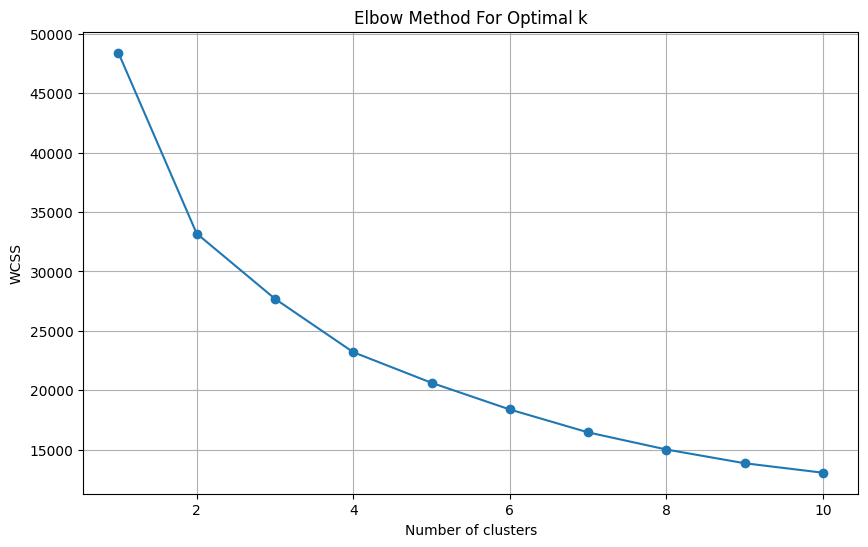

In [13]:
# Finding optimal k using the elbow method
wcss=[]
for i in range(1,11):
    kmeans=KMeans(n_clusters=i,init='k-means++',max_iter=300,n_init=10,random_state=0)
    kmeans.fit(X_train)
    wcss.append(kmeans.inertia_)

# Plotting the elbow method graph
plt.figure(figsize=(10,6))
plt.plot(range(1,11),wcss,marker='o')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.grid()
plt.show()

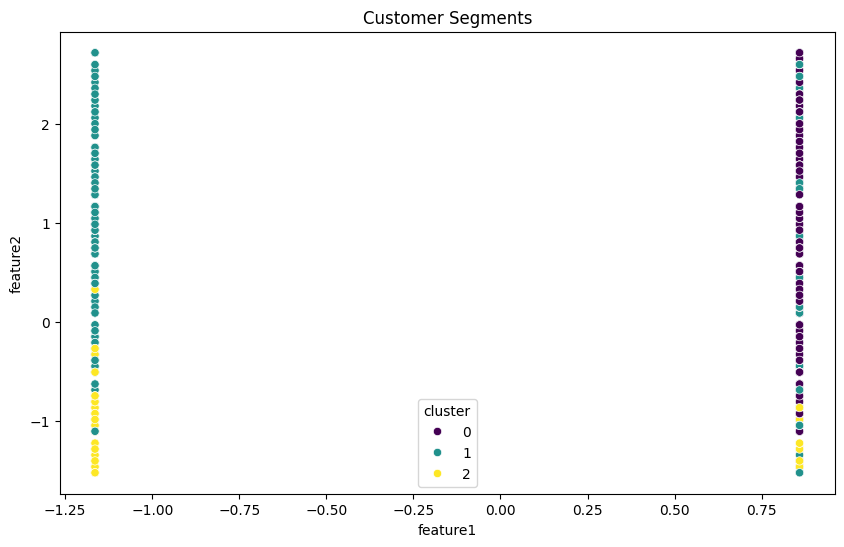

['../Outputs/models/kmeans_model.pkl']

In [14]:
# Therefore optimal value of k is 3

# Fitting KMeans to the dataset

kmeans=KMeans(n_clusters=3,init='k-means++',random_state=42)
y_kmeans=kmeans.fit_predict(X_train)

df = pd.DataFrame(X_train.iloc[:, :2].values, columns=['feature1', 'feature2'])
df['cluster']=y_kmeans

# Plotting the clusters
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x='feature1',y='feature2',hue='cluster',palette='viridis')
plt.title('Customer Segments')
plt.show()

# Saving the model
joblib.dump(kmeans,'../Outputs/models/kmeans_model.pkl')


<Axes: xlabel='PC1', ylabel='PC2'>

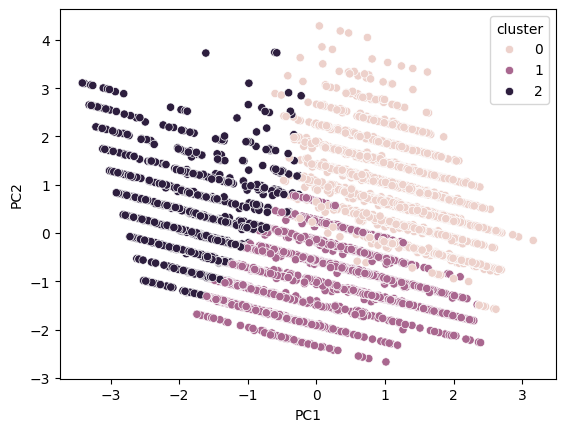

In [15]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X_train)

# Then create DataFrame with X_reduced and cluster labels
df = pd.DataFrame(X_reduced, columns=['PC1', 'PC2'])
df['cluster'] = kmeans.labels_

# Plot
sns.scatterplot(data=df, x='PC1', y='PC2', hue='cluster')


In [16]:
X_train['cluster'] = kmeans.labels_
cluster_summary = X_train.groupby('cluster').mean()
print(cluster_summary)


         Ever_Married       Age  Graduated  Profession  Spending_Score  \
cluster                                                                  
0            0.835791  0.474524   0.181319    0.341477        1.146088   
1           -0.176470  0.168881   0.317141    0.299687       -0.740216   
2           -1.053974 -0.984731  -0.738969   -0.964430       -0.729917   

         Family_Size  
cluster               
0           0.194366  
1          -0.710521  
2           0.716135  


In [17]:
# Reverting back to the original data
scaler = joblib.load('../data/preprocessed_data/scaler.pkl')
 
cluster_summary = X_train.groupby('cluster').mean()

cluster_summary_original = pd.DataFrame(
    scaler.inverse_transform(cluster_summary).round(0).astype(int),
    columns=cluster_summary.columns,
    index=cluster_summary.index
)

print(cluster_summary_original)

         Ever_Married  Age  Graduated  Profession  Spending_Score  Family_Size
cluster                                                                       
0                   1   52          1           3               2            3
1                   0   47          1           3               0            2
2                   0   27          0           1               0            4


In [18]:
# Scores
from sklearn.metrics import silhouette_score,calinski_harabasz_score, davies_bouldin_score

# Calculate silhouette score
silhouette_avg = silhouette_score(X_train, y_kmeans)
print(f'Silhouette Score: {silhouette_avg}')

# Calculate Calinski-Harabasz score
calinski_harabasz = calinski_harabasz_score(X_train, y_kmeans)
print(f'Calinski-Harabasz Score: {calinski_harabasz}')

# Calculate Davies-Bouldin score
davies_bouldin = davies_bouldin_score(X_train, y_kmeans)
print(f'Davies-Bouldin Score: {davies_bouldin}')


Silhouette Score: 0.30385298356537827
Calinski-Harabasz Score: 3743.4096646572507
Davies-Bouldin Score: 1.348373511089165


## Conclusions:
- People who spend the most are married, aged around 50, are academics, and have a family size of 3.
- People who spend the least are either single, aged around 30-45, and work in healthcare or entertainment.
